# Visualize the Education's Impact Spatially

In [1]:
import os, sys

sys.path.append(os.path.abspath("."))

In [2]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [3]:
CURRENT_ADDR

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article'

## Impact Package

In [4]:
import geopandas as gpd
import numpy as np
import os, sys
import pandas as pd

In [5]:
import LoadDataFromDisk
from VisualizeMaps import load_spatial_data, build_province_diff_df, plot_spatial_differences

## Function

## Run

In [6]:
if __name__ == '__main__':
    pass

In [7]:
os.makedirs(MLD01e1_RESULTS_ADDR := './MLD01e_Results/MLD01e1_Results/direct', exist_ok=True)

In [8]:
probs_dictionary = LoadDataFromDisk.read_all_probs_df_from_parquet(MLD01e1_RESULTS_ADDR)

In [9]:
input_name_list = ['factual_knowledge_probs', 'factual_awareness_probs', 
                   'factual_action_probs_soilandwater', 'factual_action_probs_riskreduction', 
                   'factual_action_probs_roadimprovement', 'factual_action_probs_communityparticipation']

In [10]:
map_df = load_spatial_data()

✅ Loaded spatial data with 20 intersected polygons.


In [11]:
map_df.columns = ['EcoBelt', "Province", 'geometry']

In [12]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [13]:
province_name = df_all['Prov'].unique().tolist()

In [14]:
df_diff = build_province_diff_df(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    province_column=df_all['Prov'],
    ecobelt_column=df_all['EcoBelt']
)

In [15]:
# Fix inconsistent province name
map_df.loc[map_df['Province'] == 'Sudur Pashchim', 'Province'] = 'Sudurpashchim'

# Set multi-index with Province and EcoBelt
map_df = map_df.set_index(['Province', 'EcoBelt'])

In [16]:
map_diff_df = df_diff.merge(map_df, left_index=True, right_index=True)

In [17]:
map_diff_df = gpd.GeoDataFrame(map_diff_df, geometry='geometry')

In [18]:
map_diff_df.describe()

,factual_knowledge_probs,factual_awareness_probs,factual_action_probs_soilandwater,factual_action_probs_riskreduction,factual_action_probs_roadimprovement,factual_action_probs_communityparticipation
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.049595,0.004588,0.002353,0.000424,-0.002531,-0.000410
std,0.011755,0.003237,0.002797,0.001770,0.002218,0.001199
min,0.032301,0.000924,-0.001795,-0.001284,-0.008008,-0.003075
25%,0.040219,0.002629,0.000525,-0.000572,-0.002790,-0.000941
50%,0.049399,0.003996,0.003034,-0.000080,-0.001997,-0.000045
75%,0.058490,0.005439,0.003948,0.000401,-0.001158,0.000355
max,0.071010,0.013816,0.007224,0.005349,0.000029,0.001285


In [19]:
os.makedirs(MLD01e1_FIGURE_ADDR := './MLD01e_Figures/direct', exist_ok=True)

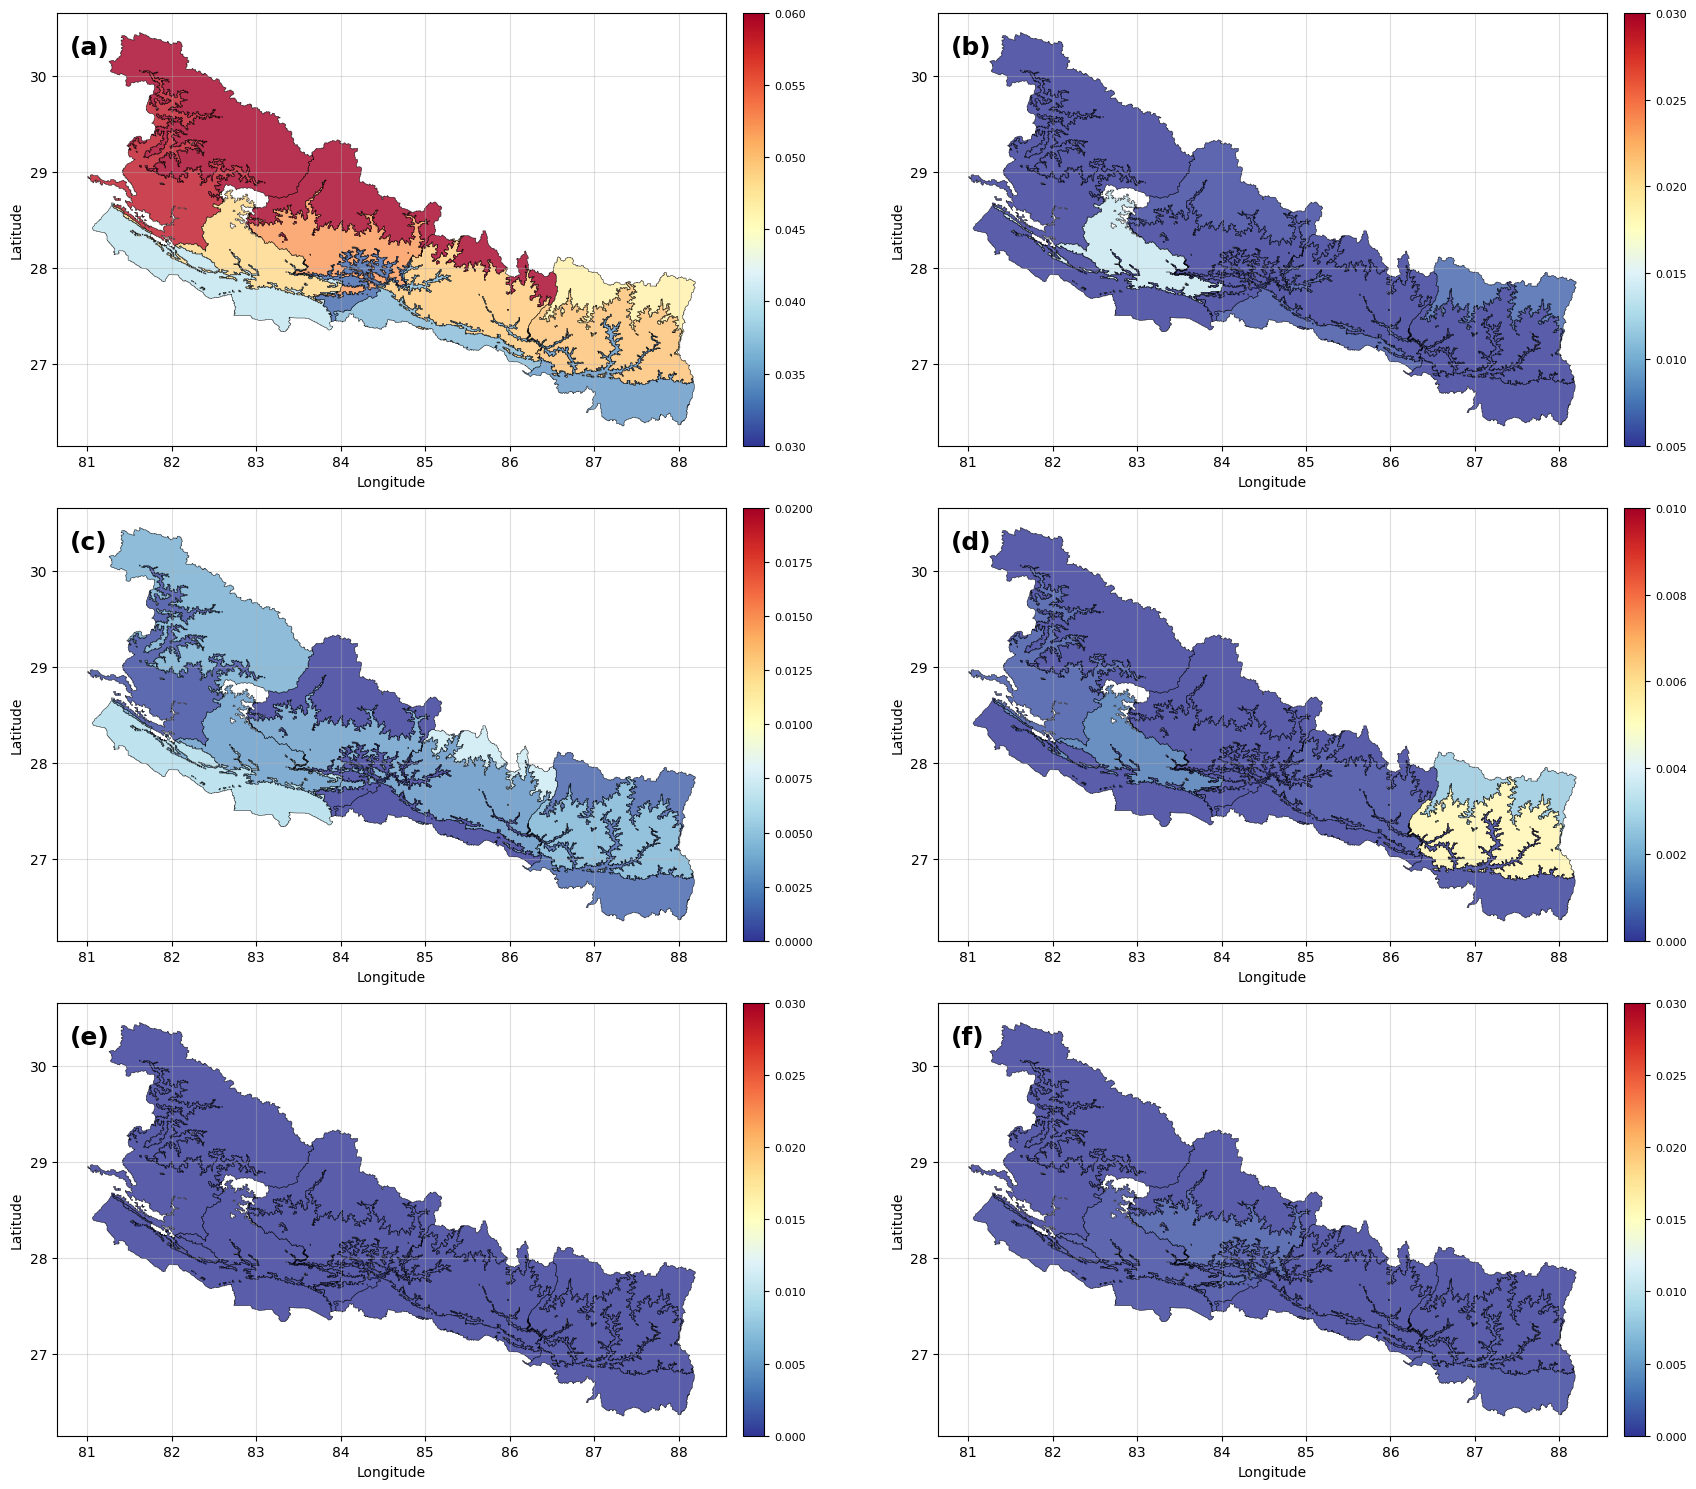

✅ Violin plots saved to: ./MLD01e_Figures/direct/MLD01e1_SpatiallyVisualizeEducationResult_v1.jpg


In [20]:
plot_spatial_differences(
    map_diff_df=map_diff_df,
    save_address=f'{MLD01e1_FIGURE_ADDR}/MLD01e1_SpatiallyVisualizeEducationResult_v1.jpg'
)